# Assignment M7: Tree Models
**George Khramtchenko - University of Connecticut**

-------------------------------------
The work contained and presented here is my work and my work alone. The following sources were used:
*   OPIM 5604 Module 7 Tree Models.ipynb
*   KhramtchenkoGeorgeOPIM5604AssignmentM5.ipynb
*   Google Gemini


# Environment Setup

In [75]:
# import modules

import pandas as pd # for data viz and wrangling
import numpy as np # for 'numeric python'
import matplotlib.pyplot as plt # for data viz (more complex than pylab)
import seaborn as sns
from pylab import * # for data viz (import * means 'import all of the functions')

from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix, roc_curve, auc
from sklearn import metrics
from scipy import stats
import statsmodels.api as sm

In [76]:
# Mount my google drive for access
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


#Load the Data

**Prompt 1:** Read in the Telco dataset and determine how many rows and columns it has.

In [77]:
df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 7/Assignment M7/Telco_customer_churn.csv')
# Obtain the number of rows and columns this data has
print(df.shape)

(7043, 18)


**Answer:** This dataset has **7,043** rows and **18** columns.

Print the head elements of each column row for initial data visualization.

In [78]:
# Preview
print(df.head())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

List all columns with their corresponding data types.

In [79]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Gender             7043 non-null   object 
 2   Senior Citizen     7043 non-null   object 
 3   Partner            7043 non-null   object 
 4   Dependents         7043 non-null   object 
 5   Tenure Months      7043 non-null   int64  
 6   Multiple Lines     7043 non-null   object 
 7   Internet Service   7043 non-null   object 
 8   Online Security    7043 non-null   object 
 9   Online Backup      7043 non-null   object 
 10  Device Protection  7043 non-null   object 
 11  Tech Support       7043 non-null   object 
 12  Contract           7043 non-null   object 
 13  Paperless Billing  7043 non-null   object 
 14  Electronic Check   7043 non-null   object 
 15  Monthly Charges    7043 non-null   float64
 16  Churn Label        7043 

We have a mix of categorical and continuous predictors. I'll change the target variable to 1s and 0s.

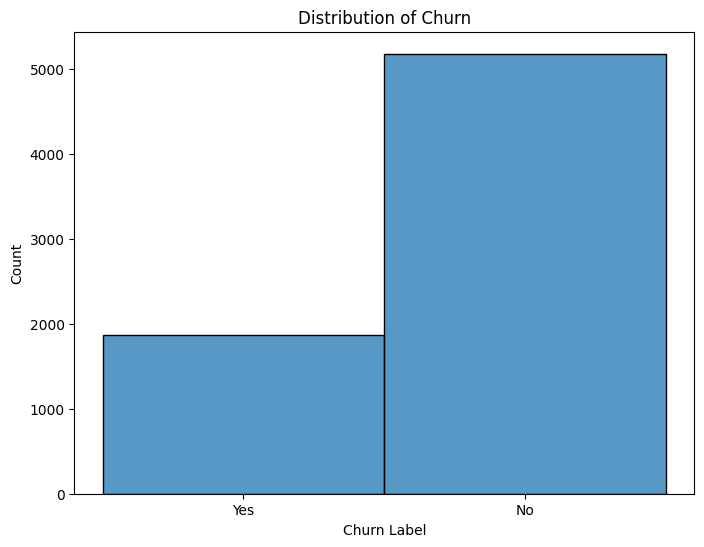


Counts of Churn Label
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [80]:
# Show a histogram of 'Churn Label' counts
plt.figure(figsize=(8, 6))
sns.histplot(data=df, x='Churn Label', bins=2) # bins=2 for two categories (0 and 1)
plt.title('Distribution of Churn')
plt.xlabel('Churn Label')
plt.ylabel('Count')
plt.xticks([0, 1]) # Set x-axis ticks at 0 and 1
plt.show()

# Display counts
churn_counts = df['Churn Label'].value_counts()
print("\nCounts of Churn Label")
print(churn_counts)

Convert the 'Churn Label' column to numerical values using map, required for logistic regression.

In [81]:
# Convert 'Churn Label' to numerical (Yes=1, No=0) using map
df['Churn Value'] = df['Churn Label'].map({'Yes': 1, 'No': 0})

# Display the first few rows and unique values to see the changes in the target variable
print(df.head())
print("\nUnique values after conversion:")
print(df['Churn Label'].unique())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

Verify the mapping changes took effect.

In [82]:
# Look at counts of 0 and 1 values for Churn Label to check our work
churn_counts = df['Churn Label'].value_counts()
print("Counts of Churn Labels (0s and 1s):")
print(churn_counts)

Counts of Churn Labels (0s and 1s):
Churn Label
No     5174
Yes    1869
Name: count, dtype: int64


In [83]:
# Display the first few rows and unique values to see the changes in the target variable
print(df.head())
print("\nUnique values after conversion:")
print(df['Churn Label'].unique())

   CustomerID  Gender Senior Citizen Partner Dependents  Tenure Months  \
0  3668-QPYBK    Male             No      No         No              2   
1  9237-HQITU  Female             No      No        Yes              2   
2  9305-CDSKC  Female             No      No        Yes              8   
3  7892-POOKP  Female             No     Yes        Yes             28   
4  0280-XJGEX    Male             No      No        Yes             49   

  Multiple Lines Internet Service Online Security Online Backup  \
0             No              DSL             Yes           Yes   
1             No      Fiber optic              No            No   
2            Yes      Fiber optic              No            No   
3            Yes      Fiber optic              No            No   
4            Yes      Fiber optic              No           Yes   

  Device Protection Tech Support        Contract Paperless Billing  \
0                No           No  Month-to-month               Yes   
1           

Drop CustomerID because it has too many categories and is irrelevant to this assignment.

In [84]:
# Drop the 'CustomerID' column
df = df.drop('CustomerID', axis=1)

Show a bar plot of the contract types to see if it can be used for dummy variables.

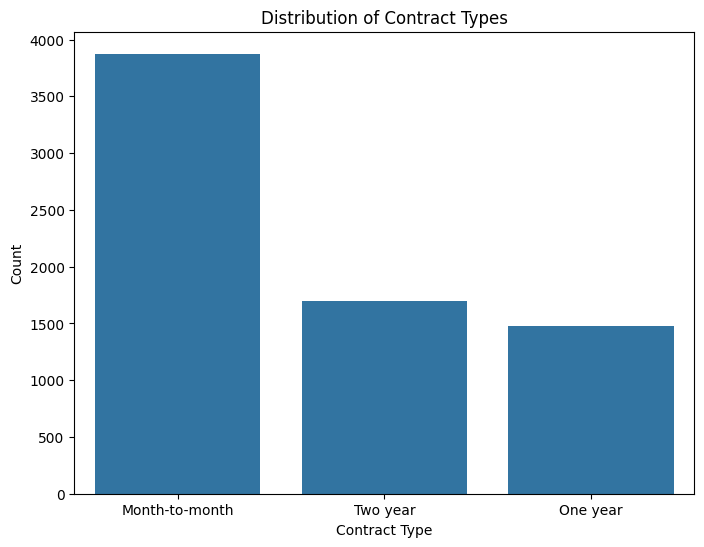


Counts of Contract Levels:
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64

Percentages of Contract Levels:
Contract
Month-to-month    55.019168
Two year          24.066449
One year          20.914383
Name: proportion, dtype: float64


In [85]:
# Show a histogram/bar plot of 'Contract' with counts
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='Contract')
plt.title('Distribution of Contract Types')
plt.xlabel('Contract Type')
plt.ylabel('Count')
plt.show()

# Display counts and percentages
contract_counts = df['Contract'].value_counts()
contract_percentages = df['Contract'].value_counts(normalize=True) * 100

print("\nCounts of Contract Levels:")
print(contract_counts)

print("\nPercentages of Contract Levels:")
print(contract_percentages)

**Prompt 3:** Partition the data into a 60/20/20 split.

*Step 1:* Create dummy variable(s) before building the logistic regression model.

In [86]:
# Create dummy variables for 'Contract'
df = pd.get_dummies(df, columns=['Contract'], drop_first=True)

# Display the first few rows to see the changes
print(df.head())

   Gender Senior Citizen Partner Dependents  Tenure Months Multiple Lines  \
0    Male             No      No         No              2             No   
1  Female             No      No        Yes              2             No   
2  Female             No      No        Yes              8            Yes   
3  Female             No     Yes        Yes             28            Yes   
4    Male             No      No        Yes             49            Yes   

  Internet Service Online Security Online Backup Device Protection  \
0              DSL             Yes           Yes                No   
1      Fiber optic              No            No                No   
2      Fiber optic              No            No               Yes   
3      Fiber optic              No            No               Yes   
4      Fiber optic              No           Yes               Yes   

  Tech Support Paperless Billing Electronic Check  Monthly Charges  \
0           No               Yes              

Partition the data to prepare for modeling, utilizing Churn Label as the target variable with the rest of the columns being used as our initial predictor variables. A 60/20/20 split will be utilized.

In [87]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Identify categorical columns to encode (excluding 'CustomerID' and 'Churn Label' and 'Churn Value' which are handled)
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Churn Label')

# Create dummy variables for all identified categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Define the target variable
target = 'Churn Label'
# Define features by dropping the original target variable and 'Churn Value'
features = df_encoded.drop([target, 'Churn Value'], axis=1)
target_variable = df_encoded[target]

# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Display the first few rows of the encoded features to verify
print("\nEncoded Features Head:")
print(features.head())

Training set shape: (4225, 18) (4225,)
Validation set shape: (1409, 18) (1409,)
Test set shape: (1409, 18) (1409,)

Encoded Features Head:
   Tenure Months  Monthly Charges  Contract_One year  Contract_Two year  \
0              2            53.85              False              False   
1              2            70.70              False              False   
2              8            99.65              False              False   
3             28           104.80              False              False   
4             49           103.70              False              False   

   Gender_Male  Senior Citizen_Yes  Partner_Yes  Dependents_Yes  \
0         True               False        False           False   
1        False               False        False            True   
2        False               False        False            True   
3        False               False         True            True   
4         True               False        False            True   

   Mult

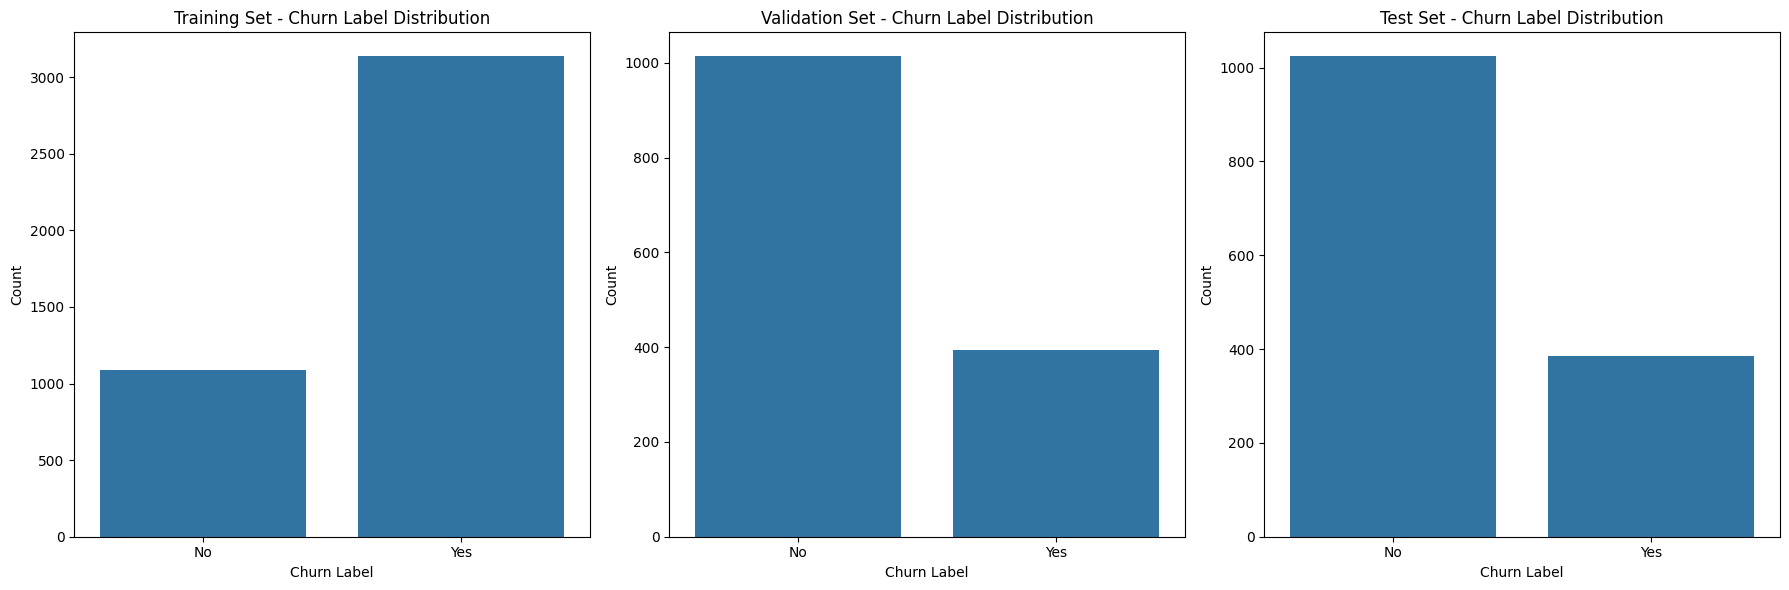

Training set Churn Label counts and percentages:
Churn Label
No     3136
Yes    1089
Name: count, dtype: int64
Churn Label
No     74.22
Yes    25.78
Name: proportion, dtype: float64

Validation set Churn Label counts and percentages:
Churn Label
No     1014
Yes     395
Name: count, dtype: int64
Churn Label
No     71.97
Yes    28.03
Name: proportion, dtype: float64

Test set Churn Label counts and percentages:
Churn Label
No     1024
Yes     385
Name: count, dtype: int64
Churn Label
No     72.68
Yes    27.32
Name: proportion, dtype: float64


In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine the features and target for plotting
train_data = X_train.copy()
train_data['Churn Label'] = y_train

val_data = X_val.copy()
val_data['Churn Label'] = y_val

test_data = X_test.copy()
test_data['Churn Label'] = y_test

# Plot the distribution of 'Churn Label' in each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

sns.countplot(data=train_data, x='Churn Label', ax=axs[0])
axs[0].set_title('Training Set - Churn Label Distribution')
axs[0].set_xlabel('Churn Label')
axs[0].set_ylabel('Count')
axs[0].set_xticks([0, 1])
axs[0].set_xticklabels(['No', 'Yes'])

sns.countplot(data=val_data, x='Churn Label', ax=axs[1])
axs[1].set_title('Validation Set - Churn Label Distribution')
axs[1].set_xlabel('Churn Label')
axs[1].set_ylabel('Count')
axs[1].set_xticks([0, 1])
axs[1].set_xticklabels(['No', 'Yes'])

sns.countplot(data=test_data, x='Churn Label', ax=axs[2])
axs[2].set_title('Test Set - Churn Label Distribution')
axs[2].set_xlabel('Churn Label')
axs[2].set_ylabel('Count')
axs[2].set_xticks([0, 1])
axs[2].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

# Print counts and percentages for each partition
print("Training set Churn Label counts and percentages:")
train_counts = train_data['Churn Label'].value_counts()
train_percentages = train_data['Churn Label'].value_counts(normalize=True) * 100
print(train_counts)
print(train_percentages.round(2)) # Round percentages to 2 decimal places

print("\nValidation set Churn Label counts and percentages:")
val_counts = val_data['Churn Label'].value_counts()
val_percentages = val_data['Churn Label'].value_counts(normalize=True) * 100
print(val_counts)
print(val_percentages.round(2)) # Round percentages to 2 decimal places

print("\nTest set Churn Label counts and percentages:")
test_counts = test_data['Churn Label'].value_counts()
test_percentages = test_data['Churn Label'].value_counts(normalize=True) * 100
print(test_counts)
print(test_percentages.round(2)) # Round percentages to 2 decimal places

# Decision Trees

**Prompt 3:** Build a decision tree model to predict churn using all predictors.

Identify the model, then fit it to the training data.  

In [89]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split

# Assuming X_train, X_val, X_test, y_train, y_val, y_test are already defined and properly encoded from previous steps

# Initialize the Decision Tree Classifier
# We can start with default parameters or set some like max_depth for initial exploration
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model on the training data
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully.")

Decision Tree model trained successfully.


**Prompt 4:** How many splits and rules does the tree have?

In [90]:
# The number of splits in a decision tree is the number of internal nodes.
# This is equal to the total number of nodes minus the number of leaf nodes.
# We can access the tree structure from the dt_model.tree_ attribute.

tree_ = dt_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves

number_of_splits = total_nodes - leaf_nodes

print(f"The decision tree has {number_of_splits} splits (internal nodes).")
print(f"The decision tree has {leaf_nodes} leaves.")

The decision tree has 873 splits (internal nodes).
The decision tree has 874 leaves.


**Answer:** This tree has **873 splits**, **874 leaves**, and **874 rules**.

Make predictions on the training, validation, and test sets.

In [91]:
# Make predictions on training set
y_train_pred_reg = dt_model.predict(X_train)

# Make predictions on validation set
y_val_pred_reg = dt_model.predict(X_val)

# Make predictions on test set
y_test_pred_reg = dt_model.predict(X_test)

Evaluate tree performance.

In [92]:
from sklearn.metrics import confusion_matrix

# Predictions on training set
y_train_pred = dt_model.predict(X_train)
cm_train = confusion_matrix(y_train, y_train_pred)

# Predictions on validation set
y_val_pred = dt_model.predict(X_val)
cm_val = confusion_matrix(y_val, y_val_pred)

# Predictions on test set
y_test_pred = dt_model.predict(X_test)
cm_test = confusion_matrix(y_test, y_test_pred)

print("Confusion Matrix - Training Set:")
print(cm_train)

print("\nConfusion Matrix - Validation Set:")
print(cm_val)

print("\nConfusion Matrix - Test Set:")
print(cm_test)

Confusion Matrix - Training Set:
[[3136    0]
 [   9 1080]]

Confusion Matrix - Validation Set:
[[843 171]
 [182 213]]

Confusion Matrix - Test Set:
[[833 191]
 [205 180]]


**Prompt 5:** Check model performance by partition with total accuracy, precision, recall, F1 score, and AUC.

In [93]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Get predicted probabilities
y_train_proba = dt_model.predict_proba(X_train)[:, 1]
y_val_proba = dt_model.predict_proba(X_val)[:, 1]
y_test_proba = dt_model.predict_proba(X_test)[:, 1]

# Convert predicted labels to numerical (Yes=1, No=0)
y_train_pred_numeric = [1 if pred == 'Yes' else 0 for pred in y_train_pred]
y_val_pred_numeric = [1 if pred == 'Yes' else 0 for pred in y_val_pred]
y_test_pred_numeric = [1 if pred == 'Yes' else 0 for pred in y_test_pred]


# Calculate metrics for Training Set
# Convert y_train to numerical labels (0 and 1) for metrics calculation
y_train_numeric = y_train.map({'Yes': 1, 'No': 0})
accuracy_train = accuracy_score(y_train_numeric, y_train_pred_numeric)
precision_train = precision_score(y_train_numeric, y_train_pred_numeric)
recall_train = recall_score(y_train_numeric, y_train_pred_numeric)
f1_train = f1_score(y_train_numeric, y_train_pred_numeric)
auc_train = roc_auc_score(y_train_numeric, y_train_proba)

print("Training Set Metrics:")
print(f"  Accuracy: {accuracy_train:.4f}")
print(f"  Precision: {precision_train:.4f}")
print(f"  Recall: {recall_train:.4f}")
print(f"  F1-Score: {f1_train:.4f}")
print(f"  AUC: {auc_train: .4f}")

# Calculate metrics for Validation Set
# Convert y_val to numerical labels (0 and 1) for metrics calculation
y_val_numeric = y_val.map({'Yes': 1, 'No': 0})
accuracy_val = accuracy_score(y_val_numeric, y_val_pred_numeric)
precision_val = precision_score(y_val_numeric, y_val_pred_numeric)
recall_val = recall_score(y_val_numeric, y_val_pred_numeric)
f1_val = f1_score(y_val_numeric, y_val_pred_numeric)
auc_val = roc_auc_score(y_val_numeric, y_val_proba)

print("\nValidation Set Metrics:")
print(f"  Accuracy: {accuracy_val:.4f}")
print(f"  Precision: {precision_val:.4f}")
print(f"  Recall: {recall_val:.4f}")
print(f"  F1-Score: {f1_val:.4f}")
print(f"  AUC: {auc_val: .4f}")

# Calculate metrics for Test Set
# Convert y_test to numerical labels (0 and 1) for metrics calculation
y_test_numeric = y_test.map({'Yes': 1, 'No': 0})
accuracy_test = accuracy_score(y_test_numeric, y_test_pred_numeric)
precision_test = precision_score(y_test_numeric, y_test_pred_numeric)
recall_test = recall_score(y_test_numeric, y_test_pred_numeric)
f1_test = f1_score(y_test_numeric, y_test_pred_numeric)
auc_test = roc_auc_score(y_test_numeric, y_test_proba)

print("\nTest Set Metrics:")
print(f"  Accuracy: {accuracy_test:.4f}")
print(f"  Precision: {precision_test:.4f}")
print(f"  Recall: {recall_test:.4f}")
print(f"  F1-Score: {f1_test:.4f}")
print(f"  AUC: {auc_test: .4f}")

Training Set Metrics:
  Accuracy: 0.9979
  Precision: 1.0000
  Recall: 0.9917
  F1-Score: 0.9959
  AUC:  1.0000

Validation Set Metrics:
  Accuracy: 0.7495
  Precision: 0.5547
  Recall: 0.5392
  F1-Score: 0.5469
  AUC:  0.6861

Test Set Metrics:
  Accuracy: 0.7189
  Precision: 0.4852
  Recall: 0.4675
  F1-Score: 0.4762
  AUC:  0.6400


**Prompt 6:** Comment on the model performance.  What did you observe in the results?

**Answer:** The results presented above indicate that there are no false positives and no false negatives in the training, validation, and testing portions of this data set, which signals that this model is overfit to training, as initial observations seem to suggest that this model is perfect, which is seldom the case.

**Prompt 7:** Check for feature importance.  Which variables are the most important?  Did any predictors go unused?

In [94]:
import pandas as pd

# Get the feature importances from the tuned decision tree model
feature_importances_tuned_dt = dt_model.feature_importances_

# Get the feature names from the training data (assuming X_train is consistent)
feature_names_dt = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_tuned_dt = pd.Series(feature_importances_tuned_dt, index=feature_names_dt)

# Sort the feature importances in descending order
sorted_feature_importances_tuned_dt = feature_importance_series_tuned_dt.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Decision Tree:")
print(sorted_feature_importances_tuned_dt)

Feature Importances for Tuned Decision Tree:
Monthly Charges                    0.304338
Tenure Months                      0.274868
Internet Service_Fiber optic       0.102727
Gender_Male                        0.033609
Electronic Check_Yes               0.032739
Dependents_Yes                     0.032649
Partner_Yes                        0.032561
Paperless Billing_Yes              0.027146
Online Backup_Yes                  0.025188
Device Protection_Yes              0.024576
Online Security_Yes                0.019867
Tech Support_Yes                   0.019406
Multiple Lines_Yes                 0.019033
Senior Citizen_Yes                 0.017322
Contract_One year                  0.012859
Internet Service_No                0.012122
Contract_Two year                  0.005499
Multiple Lines_No phone service    0.003492
dtype: float64


**Answer:** Variables that are most important include the **Monthly Charges**, **Tenure Months**, and **Internet Service_Finer optic**. No predictors went entirely unused, but all variables with values *under* the value of Internet Service_Finer optic variable were not very important.

In [95]:
# Define the parameter grid
param_grid = {
    'max_depth': range(2, 21),
    'min_samples_split': range(2, 21),
    'min_samples_leaf': range(1, 11)
}

print("Parameter grid defined:")
print(param_grid)

Parameter grid defined:
{'max_depth': range(2, 21), 'min_samples_split': range(2, 21), 'min_samples_leaf': range(1, 11)}


In [96]:
from sklearn.model_selection import GridSearchCV

# Instantiate GridSearchCV
grid_search = GridSearchCV(dt_model, param_grid, cv=5, scoring='f1', n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found:", grid_search.best_params_)
print("Best cross-validation F1-score:", grid_search.best_score_)

Best hyperparameters found: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best cross-validation F1-score: nan


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:1108: UserWarning: One or more of the test scores are non-finite: [nan nan nan ... nan nan nan]
  warnings.warn(


**Prompt 8:** Re-train the model with hyperparameter tuning.  How many splits and rules does the tree have?

Re-train the model and create the confusion matrix for viewing result distributions.

In [97]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Retrieve the best hyperparameters
best_params = grid_search.best_params_
print("Best hyperparameters:", best_params)

# Instantiate a new Decision Tree Classifier with the best hyperparameters
tuned_dt_model = DecisionTreeClassifier(**best_params, random_state=42)

# Train the tuned model on the complete training dataset
tuned_dt_model.fit(X_train, y_train)

# Make predictions on training set
y_train_pred_tuned = tuned_dt_model.predict(X_train)
cm_train_tuned = confusion_matrix(y_train, y_train_pred_tuned)

# Make predictions on validation set
y_val_pred_tuned = tuned_dt_model.predict(X_val)
cm_val_tuned = confusion_matrix(y_val, y_val_pred_tuned)

# Make predictions on test set
y_test_pred_tuned = tuned_dt_model.predict(X_test)
cm_test_tuned = confusion_matrix(y_test, y_test_pred_tuned)

print("\nConfusion Matrix - Tuned Training Set:")
print(cm_train_tuned)

print("\nConfusion Matrix - Tuned Validation Set:")
print(cm_val_tuned)

print("\nConfusion Matrix - Tuned Test Set:")
print(cm_test_tuned)

Best hyperparameters: {'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 2}

Confusion Matrix - Tuned Training Set:
[[2921  215]
 [ 666  423]]

Confusion Matrix - Tuned Validation Set:
[[950  64]
 [220 175]]

Confusion Matrix - Tuned Test Set:
[[955  69]
 [243 142]]


In [98]:
# The number of splits in a decision tree is the number of internal nodes.
# This is equal to the total number of nodes minus the number of leaf nodes.
# We can access the tree structure from the tuned_dt_model.tree_ attribute.

tree_ = tuned_dt_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves

number_of_splits = total_nodes - leaf_nodes

print(f"The decision tree has {number_of_splits} splits (internal nodes).")
print(f"The decision tree has {leaf_nodes} leaves.")

The decision tree has 3 splits (internal nodes).
The decision tree has 4 leaves.


View the final rules in an easy to read format for future use.

In [99]:
from sklearn.tree import DecisionTreeClassifier
import numpy as np

# Assuming 'tuned_dt_model' is your trained Decision Tree Classifier model
# Assuming 'X_train' is your training feature DataFrame (for feature names)

def get_decision_path_rules(tree, feature_names, node_id, current_rule, class_names):
    """Recursively gets the decision path rules and probabilities for each leaf node."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get the class distribution (counts) and total samples at the leaf
        value = tree.value[node_id][0]
        total_samples_at_leaf = np.sum(value)

        # Calculate probabilities for each class
        probabilities = value / total_samples_at_leaf

        # Format the probabilities for printing
        prob_strings = [f"{class_names[i]}: {probabilities[i]:.4f}" for i in range(len(class_names))]
        prob_output = ", ".join(prob_strings)

        print(f"Rule: {current_rule} -> Probabilities: {prob_output}")
        return

    # If it's an internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Rule for the left child
    left_rule = f"{current_rule} AND {feature_name} <= {threshold:.2f}" if current_rule else f"{feature_name} <= {threshold:.2f}"
    get_decision_path_rules(tree, feature_names, left_child, left_rule, class_names)

    # Rule for the right child
    right_rule = f"{current_rule} AND {feature_name} > {threshold:.2f}" if current_rule else f"{feature_name} > {threshold:.2f}"
    get_decision_path_rules(tree, feature_names, right_child, right_rule, class_names)

# Get the tree structure and feature names
tree_structure = tuned_dt_model.tree_
feature_names = list(X_train.columns)
class_names = ['No Personal Loan', 'Personal Loan'] # Define your class names

print("Logical rules and probabilities for each leaf of the tuned decision tree:")
# Start the recursion from the root node (node_id 0) with an empty initial rule
get_decision_path_rules(tree_structure, feature_names, 0, "", class_names)

Logical rules and probabilities for each leaf of the tuned decision tree:
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic <= 0.50 -> Probabilities: No Personal Loan: 0.7059, Personal Loan: 0.2941
Rule: Tenure Months <= 16.50 AND Internet Service_Fiber optic > 0.50 -> Probabilities: No Personal Loan: 0.3370, Personal Loan: 0.6630
Rule: Tenure Months > 16.50 AND Internet Service_Fiber optic <= 0.50 -> Probabilities: No Personal Loan: 0.9478, Personal Loan: 0.0522
Rule: Tenure Months > 16.50 AND Internet Service_Fiber optic > 0.50 -> Probabilities: No Personal Loan: 0.7285, Personal Loan: 0.2715


**Answer:** This tree now has **3 splits**, **4 leaves**, and **4 rules**.

**Prompt 9:** Check the tuned model performance by partition with total accuracy, precision, recall, F1 score, and AUC.

In [100]:
# Convert true and predicted labels to numerical (0 and 1) for metric calculations
y_train_numeric = y_train.map({'Yes': 1, 'No': 0})
y_train_pred_numeric_tuned = [1 if pred == 'Yes' else 0 for pred in y_train_pred_tuned]
y_val_numeric = y_val.map({'Yes': 1, 'No': 0})
y_val_pred_numeric_tuned = [1 if pred == 'Yes' else 0 for pred in y_val_pred_tuned]
y_test_numeric = y_test.map({'Yes': 1, 'No': 0})
y_test_pred_numeric_tuned = [1 if pred == 'Yes' else 0 for pred in y_test_pred_tuned]

# Get predicted probabilities for AUC calculation
y_train_proba_tuned = tuned_dt_model.predict_proba(X_train)[:, 1]
y_val_proba_tuned = tuned_dt_model.predict_proba(X_val)[:, 1]
y_test_proba_tuned = tuned_dt_model.predict_proba(X_test)[:, 1]


# Calculate metrics for Training Set
accuracy_train_tuned = accuracy_score(y_train_numeric, y_train_pred_numeric_tuned)
precision_train_tuned = precision_score(y_train_numeric, y_train_pred_numeric_tuned)
recall_train_tuned = recall_score(y_train_numeric, y_train_pred_numeric_tuned)
f1_train_tuned = f1_score(y_train_numeric, y_train_pred_numeric_tuned)
auc_train_tuned = roc_auc_score(y_train_numeric, y_train_proba_tuned)


print("\nTuned Training Set Metrics:")
print(f"  Accuracy: {accuracy_train_tuned:.4f}")
print(f"  Precision: {precision_train_tuned:.4f}")
print(f"  Recall: {recall_train_tuned:.4f}")
print(f"  F1-Score: {f1_train_tuned:.4f}")
print(f"  AUC: {auc_train_tuned:.4f}")

# Calculate metrics for Validation Set
accuracy_val_tuned = accuracy_score(y_val_numeric, y_val_pred_numeric_tuned)
precision_val_tuned = precision_score(y_val_numeric, y_val_pred_numeric_tuned)
recall_val_tuned = recall_score(y_val_numeric, y_val_pred_numeric_tuned)
f1_val_tuned = f1_score(y_val_numeric, y_val_pred_numeric_tuned)
auc_val_tuned = roc_auc_score(y_val_numeric, y_val_proba_tuned)

print("\nTuned Validation Set Metrics:")
print(f"  Accuracy: {accuracy_val_tuned:.4f}")
print(f"  Precision: {precision_val_tuned:.4f}")
print(f"  Recall: {recall_val_tuned:.4f}")
print(f"  F1-Score: {f1_val_tuned:.4f}")
print(f"  AUC: {auc_val_tuned:.4f}")


# Calculate metrics for Test Set
accuracy_test_tuned = accuracy_score(y_test_numeric, y_test_pred_numeric_tuned)
precision_test_tuned = precision_score(y_test_numeric, y_test_pred_numeric_tuned)
recall_test_tuned = recall_score(y_test_numeric, y_test_pred_numeric_tuned)
f1_test_tuned = f1_score(y_test_numeric, y_test_pred_numeric_tuned)
auc_test_tuned = roc_auc_score(y_test_numeric, y_test_proba_tuned)

print("\nTuned Test Set Metrics:")
print(f"  Accuracy: {accuracy_test_tuned:.4f}")
print(f"  Precision: {precision_test_tuned:.4f}")
print(f"  Recall: {recall_test_tuned:.4f}")
print(f"  F1-Score: {f1_test_tuned:.4f}")
print(f"  AUC: {auc_test_tuned:.4f}")


Tuned Training Set Metrics:
  Accuracy: 0.7915
  Precision: 0.6630
  Recall: 0.3884
  F1-Score: 0.4899
  AUC: 0.7683

Tuned Validation Set Metrics:
  Accuracy: 0.7984
  Precision: 0.7322
  Recall: 0.4430
  F1-Score: 0.5521
  AUC: 0.7777

Tuned Test Set Metrics:
  Accuracy: 0.7786
  Precision: 0.6730
  Recall: 0.3688
  F1-Score: 0.4765
  AUC: 0.7463


**Prompt 10:** How did performance change?

**Answer:** Performance improved significantly. While imperfect, the model stayed highly accurate across all three portions, with an observed spike in precision taking place, as seen in the tuned validation portion. Recall improved moderately from the training to validation portions; however, the test partition's recall score was lower by approximately 2 percent, signifying that the model ultimately got slightly worse at accurately identifying the ratio of the true positives to the total number of actual positives. As precision and recall values were moderate, the F1 score hovered in the range of 0.47 to 0.55, signifying relatively weak results. Finally, high AUC values signify that all three models are capable of accurately identifying two different classes, albeit slightly worse for the test partition.

**Prompt 11:** Check for feature importance again.  Which variables are the most important?  Did any predictors go unused?

In [101]:
import pandas as pd

# Get the feature importances from the tuned decision tree model
feature_importances_tuned_dt = tuned_dt_model.feature_importances_

# Get the feature names from the training data (assuming X_train is consistent)
feature_names_dt = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_tuned_dt = pd.Series(feature_importances_tuned_dt, index=feature_names_dt)

# Sort the feature importances in descending order
sorted_feature_importances_tuned_dt = feature_importance_series_tuned_dt.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Decision Tree:")
print(sorted_feature_importances_tuned_dt)

Feature Importances for Tuned Decision Tree:
Tenure Months                      0.512446
Internet Service_Fiber optic       0.487554
Monthly Charges                    0.000000
Contract_One year                  0.000000
Gender_Male                        0.000000
Contract_Two year                  0.000000
Partner_Yes                        0.000000
Dependents_Yes                     0.000000
Multiple Lines_No phone service    0.000000
Senior Citizen_Yes                 0.000000
Multiple Lines_Yes                 0.000000
Internet Service_No                0.000000
Online Security_Yes                0.000000
Online Backup_Yes                  0.000000
Device Protection_Yes              0.000000
Tech Support_Yes                   0.000000
Paperless Billing_Yes              0.000000
Electronic Check_Yes               0.000000
dtype: float64


**Answer:** The variables that were deemed most important were **Tenure Months** and **Internet Service_Fiber Optic**, with unused predictors consisting of **16 variables with values of zero**.

#Load the Data

**Prompt 12:** Read in the Spotify dataset and determine how many rows and columns it has.

In [102]:
# Initially, an encoding error prevented the code from running due to an issue with reading the encoding. Encoding handling was added for 'latin-1'.
try:
    df = pd.read_csv('/content/drive/MyDrive/UConn/OPIM-5604-Predictive-Modeling/Modules/Module 7/Assignment M7/spotify-2023.csv', encoding='latin-1')
    # Obtain the number of rows and columns this data has
    print(df.shape)

except UnicodeDecodeError:
    print("UnicodeDecodeError: Failed to decode the file using 'latin-1' encoding.")

(953, 24)


**Answer:** This dataset has **953** rows and **24** columns.

**Prompt 13:** The target variable for this dataset is the streams column. Check the datatype of streams. If it isn’t already int64, update it. Hint: if needed, drop a row of problematic data to get it to convert properly.

In [103]:
# View the data types of the columns
print(f"View the data types of the columns before any required changes are implemented, if necessary: \n{df.dtypes}")

# Previous code block execution attempts had failed and yielded row(s) of problematic data
# Locate and remove the problematic row(s) of data before type conversion from obj to int86
# Utilizing the 'errors='coerce' allows the missing data to be converted into a NaN without raising an exception
problematic_rows = df[pd.to_numeric(df['streams'], errors='coerce').isna()]
if not problematic_rows.empty:
    print(f"\nFound problematic row(s) in 'streams' column: {problematic_rows}")
    df.drop(problematic_rows.index, inplace=True)
    print(f"\nDropped {len(problematic_rows)} problematic row(s).")

# Once all rows with the problematic data have been dropped,
# attempt conversion from 'object' to 'int64' for the 'streams' column
# Display the data type of the 'streams' column and the head for verification
try:
    df['streams'] = df['streams'].astype('int64')
    print(f"\nUpon data correction, the 'streams' column was successfully converted to type: {df['streams'].dtypes}.")
    print(f"View the head of the 'streams' column: \n{df['streams'].head()}")

# Basic error handling
except ValueError as vr:
    print(f"\n Conversion of 'streams' column to int64 after dropping problematic row(s) failed: {vr}")

View the data types of the columns before any required changes are implemented, if necessary: 
track_name              object
artist(s)_name          object
artist_count             int64
released_year            int64
released_month           int64
released_day             int64
in_spotify_playlists     int64
in_spotify_charts        int64
streams                 object
in_apple_playlists       int64
in_apple_charts          int64
in_deezer_playlists     object
in_deezer_charts         int64
in_shazam_charts        object
bpm                      int64
key                     object
mode                    object
danceability_%           int64
valence_%                int64
energy_%                 int64
acousticness_%           int64
instrumentalness_%       int64
liveness_%               int64
speechiness_%            int64
dtype: object

Found problematic row(s) in 'streams' column:                               track_name     artist(s)_name  artist_count  \
574  Love Grows (Where 

**Prompt 14:** Partition the data into a 60/20/20 split.

In [104]:
from sklearn.model_selection import train_test_split
import pandas as pd

# Define the target variable
target = 'streams'
features = df.drop(target, axis=1)

# Identify and drop non-numeric columns that are not suitable for direct use in a regression tree
cols_to_drop = ['track_name', 'artist(s)_name']
features = features.drop(cols_to_drop, axis=1)

# Identify columns that might contain non-numeric values that should be numeric
potential_numeric_cols = ['in_deezer_playlists', 'in_shazam_charts']

for col in potential_numeric_cols:
    # Attempt to convert to numeric, coercing errors to NaN
    features[col] = pd.to_numeric(features[col], errors='coerce')

# Drop rows with NaN values that resulted from the coercion
features.dropna(inplace=True)
target_variable = df.loc[features.index, target] # Align target variable with cleaned features

# Identify categorical columns to encode (excluding the target variable and columns already dropped)
categorical_cols_to_encode = features.select_dtypes(include='object').columns.tolist()

# Create dummy variables for the identified categorical columns
features_encoded = pd.get_dummies(features, columns=categorical_cols_to_encode, drop_first=True)


# Step 1: Split into 60% training and 40% remaining data to be used for validation and testing (test_size)
X_train, X_temp, y_train, y_temp = train_test_split(features_encoded, target_variable, test_size=0.4, random_state=42)

# Step 2: Split the 40% remaining data in half (20% for validation, 20% for test with test_size being 50% of the current data (out of the remainder of the 40%)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# Print the final shapes to verify
print("Training set shape:", X_train.shape, y_train.shape)
print("Validation set shape:", X_val.shape, y_val.shape)
print("Test set shape:", X_test.shape, y_test.shape)

# Display the first few rows of the encoded features to verify
print("\nEncoded Features Head:")
print(features_encoded.head())

Training set shape: (448, 30) (448,)
Validation set shape: (150, 30) (150,)
Test set shape: (150, 30) (150,)

Encoded Features Head:
   artist_count  released_year  released_month  released_day  \
0             2           2023               7            14   
1             1           2023               3            23   
2             1           2023               6            30   
3             1           2019               8            23   
4             1           2023               5            18   

   in_spotify_playlists  in_spotify_charts  in_apple_playlists  \
0                   553                147                  43   
1                  1474                 48                  48   
2                  1397                113                  94   
3                  7858                100                 116   
4                  3133                 50                  84   

   in_apple_charts  in_deezer_playlists  in_deezer_charts  ...  key_B  key_C#  \
0   

**Prompt 15:** Build a regression tree model to predict streams using all predictors.

In [105]:
from sklearn.tree import DecisionTreeRegressor

# Initialize the Decision Tree Regressor
# We can start with default parameters for an initial model
reg_tree_model = DecisionTreeRegressor(random_state=42)

# Train the model on the training data
reg_tree_model.fit(X_train, y_train)

print("Regression Tree model trained successfully.")

Regression Tree model trained successfully.


Inspect the tree.

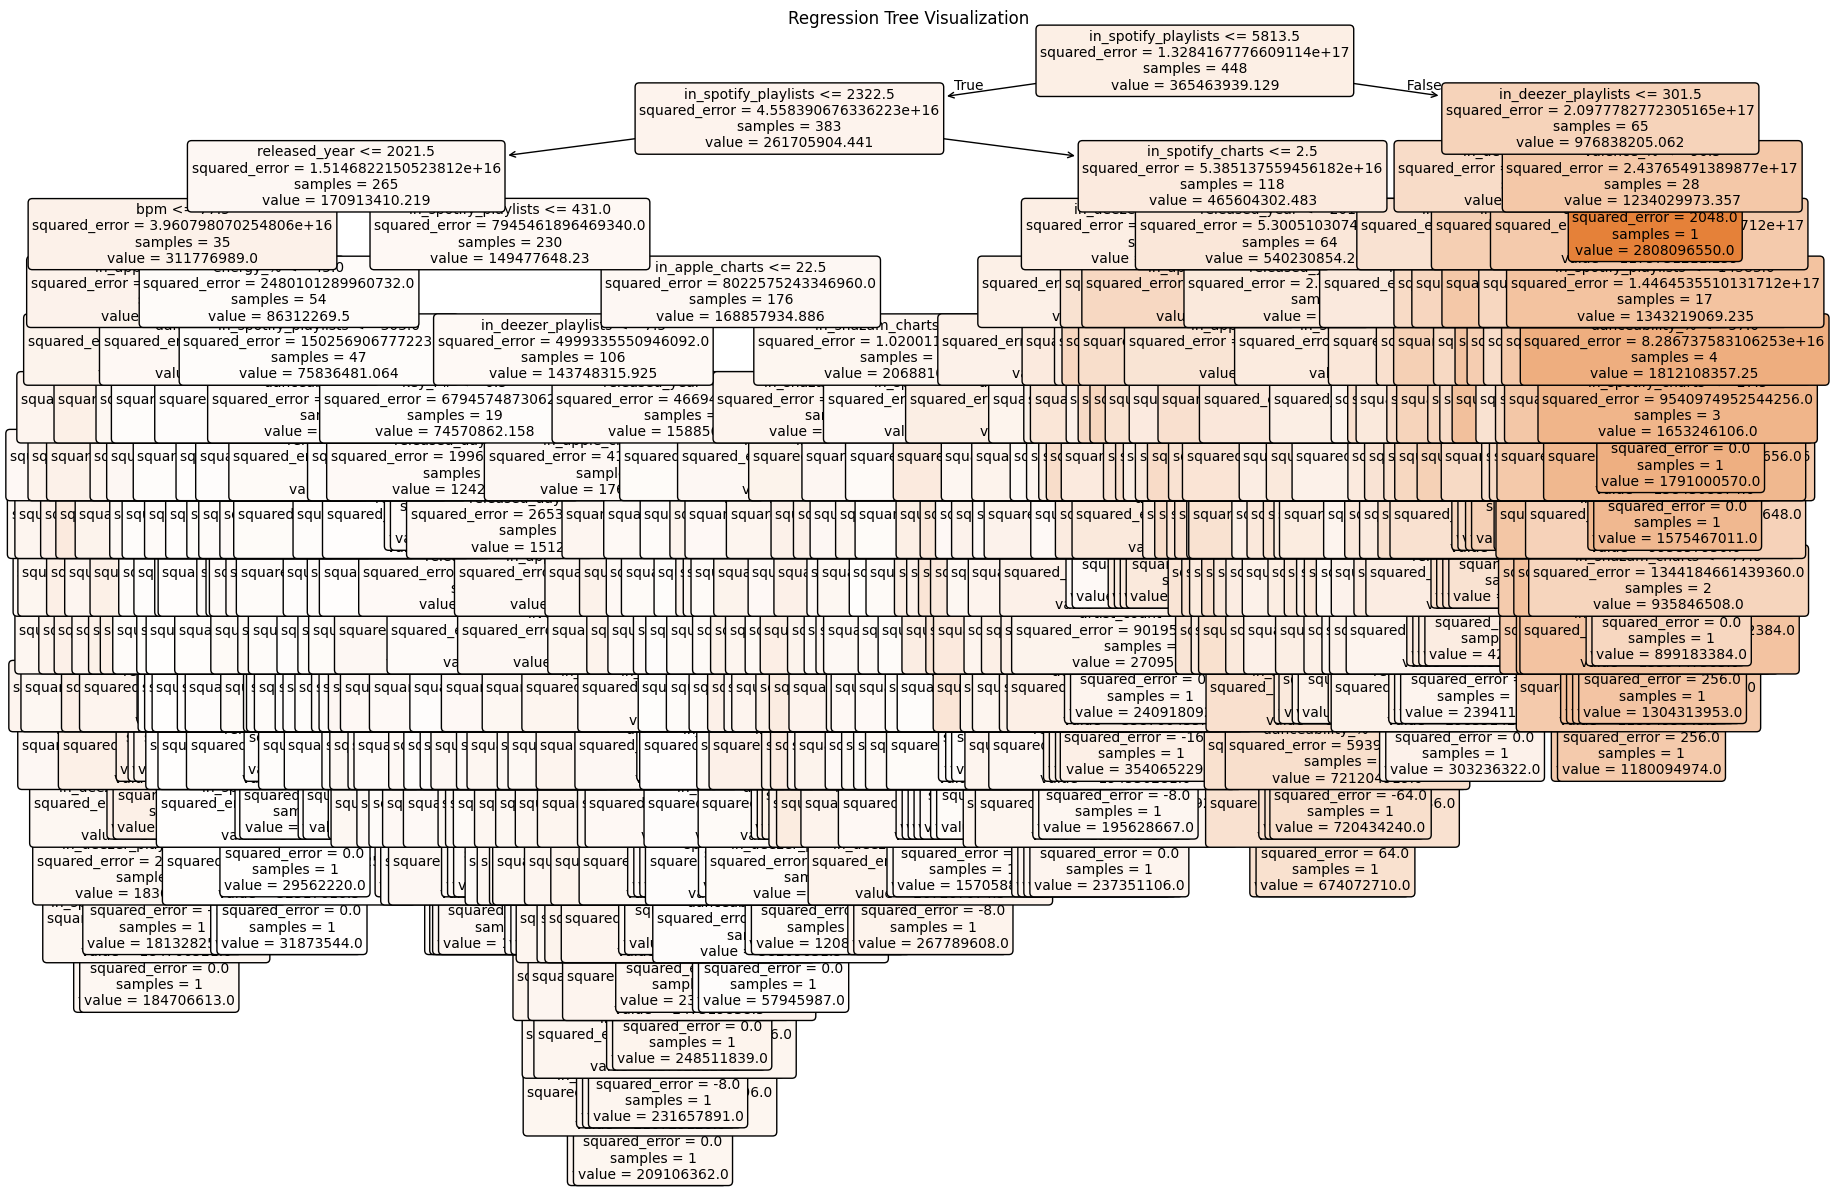

In [106]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Set the figure size for better visualization
plt.figure(figsize=(20, 15))

# Plot the regression tree
plot_tree(reg_tree_model,
          feature_names=list(X_train.columns), # Use feature names from the training data
          filled=True, # Color nodes based on the predicted value
          rounded=True, # Round node corners
          fontsize=10) # Adjust font size for readability

plt.title('Regression Tree Visualization')
plt.show()

In [107]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Calculate the number of splits and leaves
tree_ = reg_tree_model.tree_
total_nodes = tree_.node_count
leaf_nodes = tree_.n_leaves
number_of_splits = total_nodes - leaf_nodes

print(f"The regression tree has {number_of_splits} splits (internal nodes).")
print(f"The regression tree has {leaf_nodes} leaves.")
print(f"The regression tree has {leaf_nodes} rules.")

The regression tree has 447 splits (internal nodes).
The regression tree has 448 leaves.
The regression tree has 448 rules.


In [108]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Assuming 'tuned_reg_tree_model' is your trained Decision Tree Regressor model
# Assuming 'X_train' is your training feature DataFrame (for feature names)

def get_regression_path_rules(tree, feature_names, node_id, current_rule):
    """Recursively gets the decision path rules and predicted values for each leaf node in a regression tree."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get the predicted value (mean of the target variable) at the leaf
        predicted_value = tree.value[node_id][0][0]
        print(f"Rule: {current_rule} -> Predicted Value: {predicted_value:.4f}")
        return

    # If it's an internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Rule for the left child
    left_rule = f"{current_rule} AND {feature_name} <= {threshold:.2f}" if current_rule else f"{feature_name} <= {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, left_child, left_rule)

    # Rule for the right child
    right_rule = f"{current_rule} AND {feature_name} > {threshold:.2f}" if current_rule else f"{feature_name} > {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, right_child, right_rule)

# Get the tree structure and feature names
tree_structure_reg = reg_tree_model.tree_
feature_names_reg = list(X_train.columns)

print("Logical rules and predicted values for each leaf of the tuned regression tree:")
# Start the recursion from the root node (node_id 0) with an empty initial rule
get_regression_path_rules(tree_structure_reg, feature_names_reg, 0, "")

Logical rules and predicted values for each leaf of the tuned regression tree:
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND bpm <= 77.50 -> Predicted Value: 1223481149.0000
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND bpm > 77.50 AND in_apple_charts <= 120.00 AND danceability_% <= 74.00 AND released_month <= 6.00 AND artist_count <= 2.00 AND valence_% <= 42.50 AND in_deezer_playlists <= 84.50 -> Predicted Value: 156658366.0000
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND bpm > 77.50 AND in_apple_charts <= 120.00 AND danceability_% <= 74.00 AND released_month <= 6.00 AND artist_count <= 2.00 AND valence_% <= 42.50 AND in_deezer_playlists > 84.50 -> Predicted Value: 154356956.0000
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND bpm > 77.50 AND in_

**Prompt 16:** How many splits and rules does the tree have?

**Answer:** This tree has **447 splits**, **448 leaves**, and **448 rules**.

**Prompt 17:** Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

In [109]:
# Make predictions on training set
y_train_pred_reg = reg_tree_model.predict(X_train)

# Make predictions on validation set
y_val_pred_reg = reg_tree_model.predict(X_val)

# Make predictions on test set
y_test_pred_reg = reg_tree_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_reg = np.sqrt(mean_squared_error(y_train, y_train_pred_reg))
r2_train_reg = r2_score(y_train, y_train_pred_reg)

print("\nRegression Tree Performance on Training Set:")
print(f"  RMSE: {rmse_train_reg:.4f}")
print(f"  R-squared: {r2_train_reg:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_reg = np.sqrt(mean_squared_error(y_val, y_val_pred_reg))
r2_val_reg = r2_score(y_val, y_val_pred_reg)

print("\nRegression Tree Performance on Validation Set:")
print(f"  RMSE: {rmse_val_reg:.4f}")
print(f"  R-squared: {r2_val_reg:.4f}")

# Calculate and print metrics for Test Set
rmse_test_reg = np.sqrt(mean_squared_error(y_test, y_test_pred_reg))
r2_test_reg = r2_score(y_test, y_test_pred_reg)

print("\nRegression Tree Performance on Test Set:")
print(f"  RMSE: {rmse_test_reg:.4f}")
print(f"  R-squared: {r2_test_reg:.4f}")


Regression Tree Performance on Training Set:
  RMSE: 0.0000
  R-squared: 1.0000

Regression Tree Performance on Validation Set:
  RMSE: 283904747.6997
  R-squared: 0.3873

Regression Tree Performance on Test Set:
  RMSE: 306097539.5381
  R-squared: 0.2857


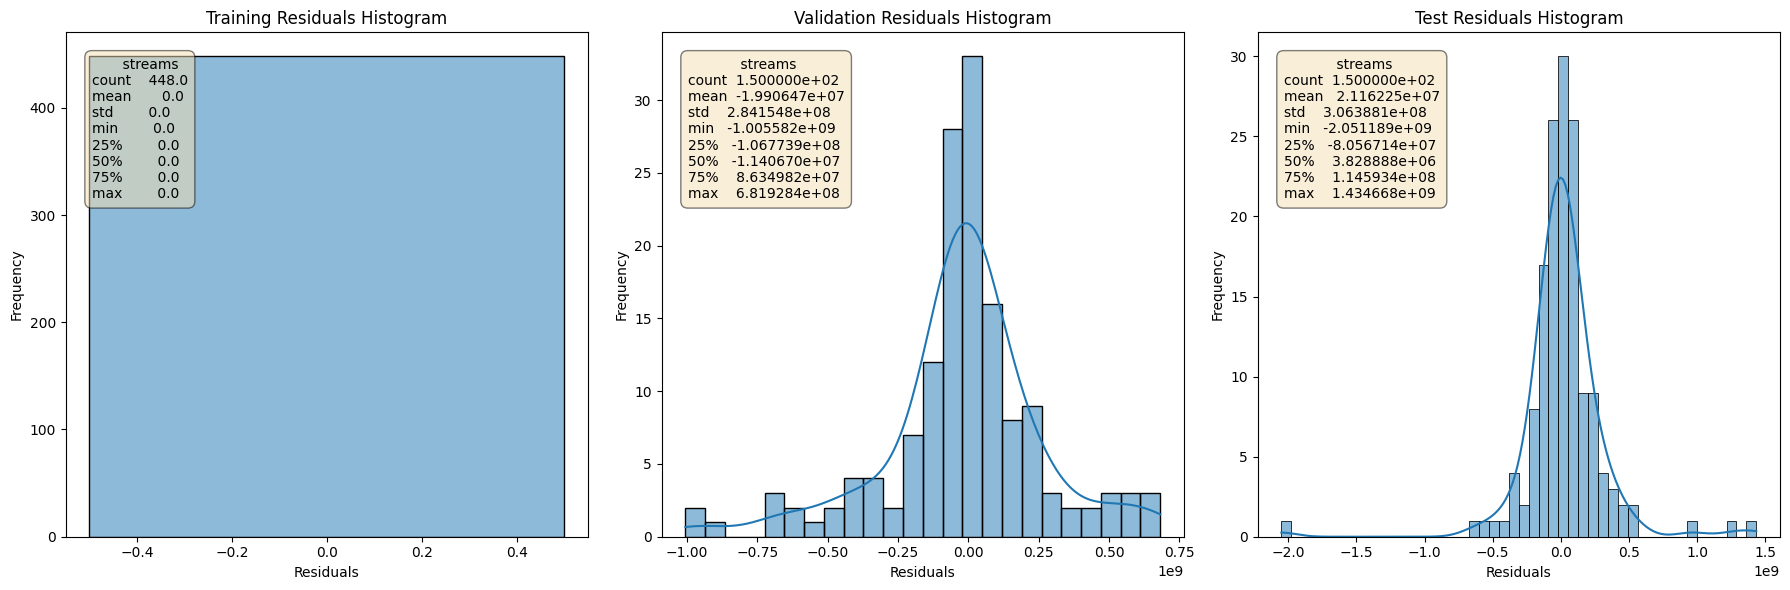

In [110]:
# Calculate residuals for each partition
train_residuals = y_train - y_train_pred_reg
val_residuals = y_val - y_val_pred_reg
test_residuals = y_test - y_test_pred_reg

# Plot histograms of the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Residuals
sns.histplot(train_residuals, kde=True, ax=axs[0])
axs[0].set_title('Training Residuals Histogram')
axs[0].set_xlabel('Residuals')
axs[0].set_ylabel('Frequency')
train_stats = pd.DataFrame(train_residuals).describe().round(2) # Round to 2 decimal places
axs[0].text(0.05, 0.95, train_stats.to_string(), transform=axs[0].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Validation Residuals
sns.histplot(val_residuals, kde=True, ax=axs[1])
axs[1].set_title('Validation Residuals Histogram')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
val_stats = pd.DataFrame(val_residuals).describe().round(2) # Round to 2 decimal places
axs[1].text(0.05, 0.95, val_stats.to_string(), transform=axs[1].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Test Residuals
sns.histplot(test_residuals, kde=True, ax=axs[2])
axs[2].set_title('Test Residuals Histogram')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')
test_stats = pd.DataFrame(test_residuals).describe().round(2) # Round to 2 decimal places
axs[2].text(0.05, 0.95, test_stats.to_string(), transform=axs[2].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

In [111]:
# Remove the extreme negative value of min in the test residuals histogram
test_residuals = test_residuals[test_residuals > test_residuals.min()]

# Create dataframes with actual and predicted prices
# This is to ensure the plotting code has the necessary dataframes
if 'train_results' not in locals() or 'val_results' not in locals() or 'test_results' not in locals():
    train_results = X_train.copy()
    train_results['Actual_Streams'] = y_train
    train_results['Predicted_Streams'] = y_train_pred_reg

    val_results = X_val.copy()
    val_results['Actual_Streams'] = y_val
    val_results['Predicted_Streams'] = y_val_pred_reg

    test_results = X_test.copy()
    test_results['Actual_Streams'] = y_test
    test_results['Predicted_Streams'] = y_test_pred_reg

Dataframes with actual and predicted streams created.


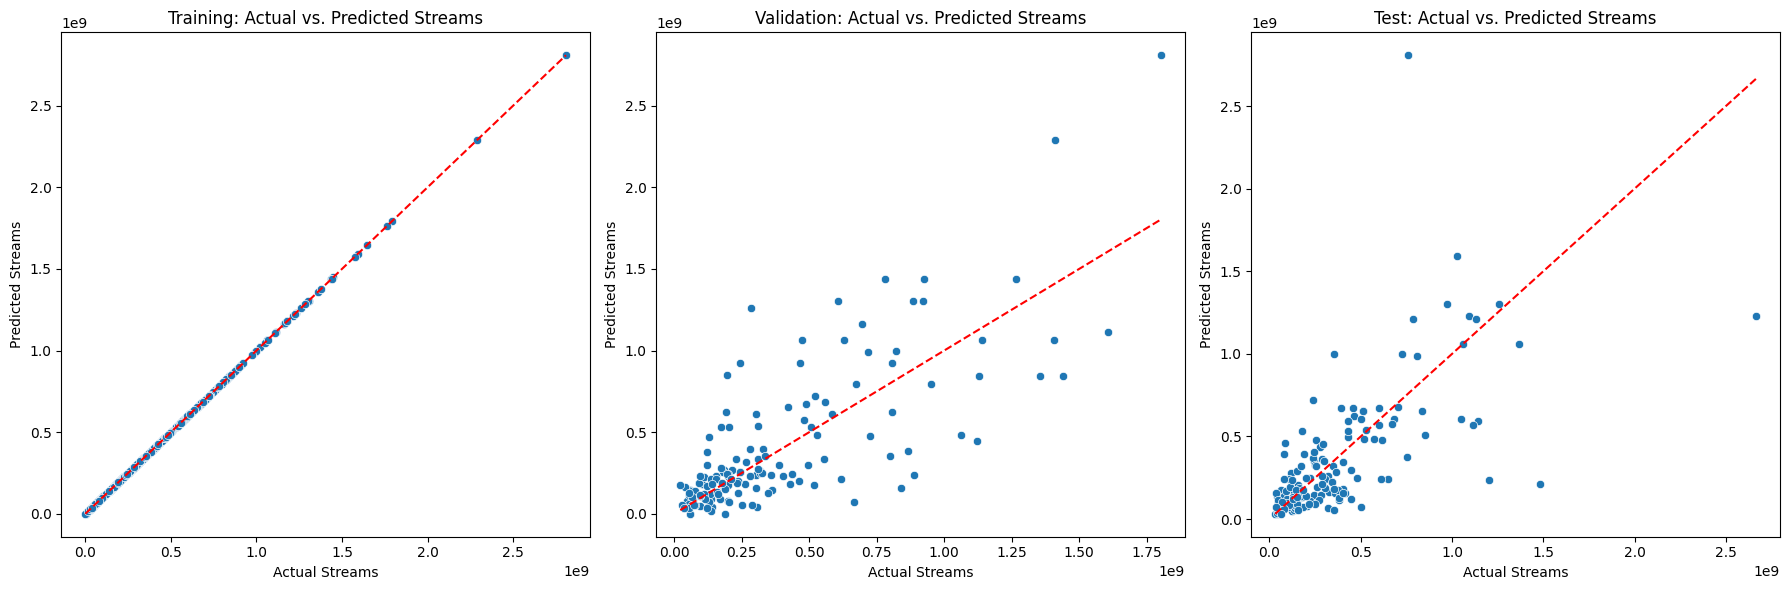

In [112]:
# Plot actual vs. predicted prices for each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=train_results, ax=axs[0])
axs[0].set_title('Training: Actual vs. Predicted Streams')
axs[0].set_xlabel('Actual Streams')
axs[0].set_ylabel('Predicted Streams')
axs[0].plot([train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           [train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Validation Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=val_results, ax=axs[1])
axs[1].set_title('Validation: Actual vs. Predicted Streams')
axs[1].set_xlabel('Actual Streams')
axs[1].set_ylabel('Predicted Streams')
axs[1].plot([val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           [val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Test Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=test_results, ax=axs[2])
axs[2].set_title('Test: Actual vs. Predicted Streams')
axs[2].set_xlabel('Actual Streams')
axs[2].set_ylabel('Predicted Streams')
axs[2].plot([test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           [test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

print("Dataframes with actual and predicted streams created.")
plt.tight_layout()
plt.show()

**Prompt 18:** Comment on the model performance.  What did you observe in the results?

**Answer:** The test partition's RMSE score was highest among all partitions, signifying this model's predictions were not as accurate and not as close to the actual values as the validation partition was, for example. The R-squared measurement suffered significantly between the validation and test partitions, indicating a 10% drop. A drop of such significance means that this model was poorly fit and could not accurately express variance in the dependent variable. The residual histograms yielded some extreme values, particularly for the testing partition, and showed an increased mean and standard deviation. Finally, the actual vs. predicted streams scatterplots showed that the test partition performed poorer than the training or validation partitions.

**Prompt 19:** Check for feature importance.  Which variables are the most important?  Did any predictors go unused?

In [113]:
import pandas as pd

# Get the feature importances from the tuned regression tree model
feature_importances_tuned_reg_tree = reg_tree_model.feature_importances_

# Get the feature names from the training data (assuming X_train is consistent)
feature_names_reg_tree = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_tuned_reg_tree = pd.Series(feature_importances_tuned_reg_tree, index=feature_names_reg_tree)

# Sort the feature importances in descending order
sorted_feature_importances_tuned_reg_tree = feature_importance_series_tuned_reg_tree.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Regression Tree:")
print(sorted_feature_importances_tuned_reg_tree)

Feature Importances for Tuned Regression Tree:
in_spotify_playlists    6.325916e-01
in_deezer_playlists     7.088562e-02
valence_%               4.506954e-02
released_year           3.623241e-02
acousticness_%          3.248936e-02
in_deezer_charts        2.627520e-02
bpm                     2.557981e-02
in_apple_charts         2.227913e-02
in_apple_playlists      2.045503e-02
in_shazam_charts        2.027642e-02
danceability_%          1.972362e-02
in_spotify_charts       1.500873e-02
liveness_%              9.344688e-03
energy_%                7.757782e-03
speechiness_%           5.593327e-03
released_day            4.018475e-03
released_month          3.204224e-03
artist_count            8.642947e-04
mode_Minor              6.220789e-04
key_F                   5.539309e-04
key_G                   4.073996e-04
key_C#                  3.254818e-04
key_B                   2.735283e-04
key_F#                  1.026937e-04
key_E                   5.036636e-05
key_A#                  8.13

**Answer:** The **in_spotify_playlists**, **in_deezer_playlists**, **valence_%**, **released_year**, and **acousticness_%** were the most important variables. The **key_G#** variable was unused.

**Prompt 20:** Re-train the model with hyperparameter tuning. How many splits and rules does the tree have?

In [114]:
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, make_scorer

# Define the parameter grid
param_grid_reg = {
    'max_depth': range(2, 21),
    'min_samples_split': range(2, 21),
    'min_samples_leaf': range(1, 11)
}

# Create a scorer for negative mean squared error (GridSearchCV maximizes scores)
neg_mse_scorer = make_scorer(mean_squared_error, greater_is_better=False)

# Instantiate GridSearchCV
# Use the original reg_tree_model as the estimator
grid_search_reg = GridSearchCV(reg_tree_model, param_grid_reg, cv=5, scoring=neg_mse_scorer, n_jobs=-1)

# Fit GridSearchCV to the training data
grid_search_reg.fit(X_train, y_train)

# Print the best hyperparameters and best cross-validation score
print("Best hyperparameters found:", grid_search_reg.best_params_)
# Convert the best score back to positive MSE or RMSE for easier interpretation
best_mse = -grid_search_reg.best_score_
best_rmse = np.sqrt(best_mse)
print(f"Best cross-validation RMSE: {best_rmse:.4f}")

Best hyperparameters found: {'max_depth': 4, 'min_samples_leaf': 7, 'min_samples_split': 18}
Best cross-validation RMSE: 231587390.0392


In [115]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Retrieve the best hyperparameters for the regression tree
best_params_reg = grid_search_reg.best_params_
print("Best hyperparameters for Regression Tree:", best_params_reg)

# Instantiate a new Decision Tree Regressor with the best hyperparameters
tuned_reg_tree_model = DecisionTreeRegressor(**best_params_reg, random_state=42)

# Train the tuned model on the complete training dataset
tuned_reg_tree_model.fit(X_train, y_train)

# Calculate the number of splits and leaves for the tuned tree
tree_tuned_reg = tuned_reg_tree_model.tree_
total_nodes_tuned_reg = tree_tuned_reg.node_count
leaf_nodes_tuned_reg = tree_tuned_reg.n_leaves
number_of_splits_tuned_reg = total_nodes_tuned_reg - leaf_nodes_tuned_reg

print(f"\nTuned Regression Tree:")
print(f"  Number of splits (internal nodes): {number_of_splits_tuned_reg}")
print(f"  Number of leaves: {leaf_nodes_tuned_reg}")


# Make predictions on training set
y_train_pred_tuned_reg = tuned_reg_tree_model.predict(X_train)

# Make predictions on validation set
y_val_pred_tuned_reg = tuned_reg_tree_model.predict(X_val)

# Make predictions on test set
y_test_pred_tuned_reg = tuned_reg_tree_model.predict(X_test)

Best hyperparameters for Regression Tree: {'max_depth': 4, 'min_samples_leaf': 7, 'min_samples_split': 18}

Tuned Regression Tree:
  Number of splits (internal nodes): 13
  Number of leaves: 14


In [116]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Assuming 'tuned_reg_tree_model' is your trained Decision Tree Regressor model
# Assuming 'X_train' is your training feature DataFrame (for feature names)

def get_regression_path_rules(tree, feature_names, node_id, current_rule):
    """Recursively gets the decision path rules and predicted values for each leaf node in a regression tree."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get the predicted value (mean of the target variable) at the leaf
        predicted_value = tree.value[node_id][0][0]
        print(f"Rule: {current_rule} -> Predicted Value: {predicted_value:.4f}")
        return

    # If it's an internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Rule for the left child
    left_rule = f"{current_rule} AND {feature_name} <= {threshold:.2f}" if current_rule else f"{feature_name} <= {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, left_child, left_rule)

    # Rule for the right child
    right_rule = f"{current_rule} AND {feature_name} > {threshold:.2f}" if current_rule else f"{feature_name} > {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, right_child, right_rule)

# Get the tree structure and feature names
tree_structure_reg = tuned_reg_tree_model.tree_
feature_names_reg = list(X_train.columns)

print("Logical rules and predicted values for each leaf of the tuned regression tree:")
# Start the recursion from the root node (node_id 0) with an empty initial rule
get_regression_path_rules(tree_structure_reg, feature_names_reg, 0, "")

Logical rules and predicted values for each leaf of the tuned regression tree:
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND speechiness_% <= 21.50 -> Predicted Value: 277412878.9643
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND speechiness_% > 21.50 -> Predicted Value: 449233429.1429
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year > 2021.50 AND in_spotify_playlists <= 431.00 -> Predicted Value: 86312269.5000
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year > 2021.50 AND in_spotify_playlists > 431.00 -> Predicted Value: 168857934.8864
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists > 2322.50 AND in_spotify_charts <= 2.50 AND in_spotify_playlists <= 3662.00 -> Predicted Value: 304225277.1212
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists > 2322.50 AND

In [117]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np

# Assuming 'tuned_reg_tree_model' is your trained Decision Tree Regressor model
# Assuming 'X_train' is your training feature DataFrame (for feature names)

def get_regression_path_rules(tree, feature_names, node_id, current_rule):
    """Recursively gets the decision path rules and predicted values for each leaf node in a regression tree."""
    left_child = tree.children_left[node_id]
    right_child = tree.children_right[node_id]

    # If it's a leaf node
    if left_child == -1 and right_child == -1:
        # Get the predicted value (mean of the target variable) at the leaf
        predicted_value = tree.value[node_id][0][0]
        print(f"Rule: {current_rule} -> Predicted Value: {predicted_value:.4f}")
        return

    # If it's an internal node
    feature_index = tree.feature[node_id]
    threshold = tree.threshold[node_id]
    feature_name = feature_names[feature_index]

    # Rule for the left child
    left_rule = f"{current_rule} AND {feature_name} <= {threshold:.2f}" if current_rule else f"{feature_name} <= {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, left_child, left_rule)

    # Rule for the right child
    right_rule = f"{current_rule} AND {feature_name} > {threshold:.2f}" if current_rule else f"{feature_name} > {threshold:.2f}"
    get_regression_path_rules(tree, feature_names, right_child, right_rule)

# Get the tree structure and feature names
tree_structure_reg = tuned_reg_tree_model.tree_
feature_names_reg = list(X_train.columns)

print("Logical rules and predicted values for each leaf of the tuned regression tree:")
# Start the recursion from the root node (node_id 0) with an empty initial rule
get_regression_path_rules(tree_structure_reg, feature_names_reg, 0, "")

Logical rules and predicted values for each leaf of the tuned regression tree:
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND speechiness_% <= 21.50 -> Predicted Value: 277412878.9643
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year <= 2021.50 AND speechiness_% > 21.50 -> Predicted Value: 449233429.1429
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year > 2021.50 AND in_spotify_playlists <= 431.00 -> Predicted Value: 86312269.5000
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists <= 2322.50 AND released_year > 2021.50 AND in_spotify_playlists > 431.00 -> Predicted Value: 168857934.8864
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists > 2322.50 AND in_spotify_charts <= 2.50 AND in_spotify_playlists <= 3662.00 -> Predicted Value: 304225277.1212
Rule: in_spotify_playlists <= 5813.50 AND in_spotify_playlists > 2322.50 AND

**Answer:** This tree now has **13 splits**, **14 leaves**, and **14 rules**.

**Prompt 21:** Check model performance by partition with RMSE, R Squared, distribution of residuals, and actual by predicted plots.

In [118]:
# Make predictions on training set
y_train_pred_tuned_reg = tuned_reg_tree_model.predict(X_train)

# Make predictions on validation set
y_val_pred_tuned_reg = tuned_reg_tree_model.predict(X_val)

# Make predictions on test set
y_test_pred_tuned_reg = tuned_reg_tree_model.predict(X_test)

# Calculate and print metrics for Training Set
rmse_train_tuned_reg = np.sqrt(mean_squared_error(y_train, y_train_pred_tuned_reg))
r2_train_tuned_reg = r2_score(y_train, y_train_pred_tuned_reg)

print("\nTuned Regression Tree Performance on Training Set:")
print(f"  RMSE: {rmse_train_tuned_reg:.4f}")
print(f"  R-squared: {r2_train_tuned_reg:.4f}")

# Calculate and print metrics for Validation Set
rmse_val_tuned_reg = np.sqrt(mean_squared_error(y_val, y_val_pred_tuned_reg))
r2_val_tuned_reg = r2_score(y_val, y_val_pred_tuned_reg)

print("\nTuned Regression Tree Performance on Validation Set:")
print(f"  RMSE: {rmse_val_tuned_reg:.4f}")
print(f"  R-squared: {r2_val_tuned_reg:.4f}")


# Calculate and print metrics for Test Set
rmse_test_tuned_reg = np.sqrt(mean_squared_error(y_test, y_test_pred_tuned_reg))
r2_test_tuned_reg = r2_score(y_test, y_test_pred_tuned_reg)

print("\nTuned Regression Tree Performance on Test Set:")
print(f"  RMSE: {rmse_test_tuned_reg:.4f}")
print(f"  R-squared: {r2_test_tuned_reg:.4f}")


Tuned Regression Tree Performance on Training Set:
  RMSE: 166893670.0842
  R-squared: 0.7903

Tuned Regression Tree Performance on Validation Set:
  RMSE: 233160079.0090
  R-squared: 0.5868

Tuned Regression Tree Performance on Test Set:
  RMSE: 252315713.5997
  R-squared: 0.5146


In [119]:
# Remove the extreme negative value of min in the test residuals histogram
test_residuals = test_residuals[test_residuals > test_residuals.min()]

# Create dataframes with actual and predicted prices
# This is to ensure the plotting code has the necessary dataframes
if 'train_results' not in locals() or 'val_results' not in locals() or 'test_results' not in locals():
    train_results = X_train.copy()
    train_results['Actual_Streams'] = y_train
    train_results['Predicted_Streams'] = y_train_pred_tuned_reg

    val_results = X_val.copy()
    val_results['Actual_Streams'] = y_val
    val_results['Predicted_Streams'] = y_val_pred_tuned_reg

    test_results = X_test.copy()
    test_results['Actual_Streams'] = y_test
    test_results['Predicted_Streams'] = y_test_pred_tuned_reg

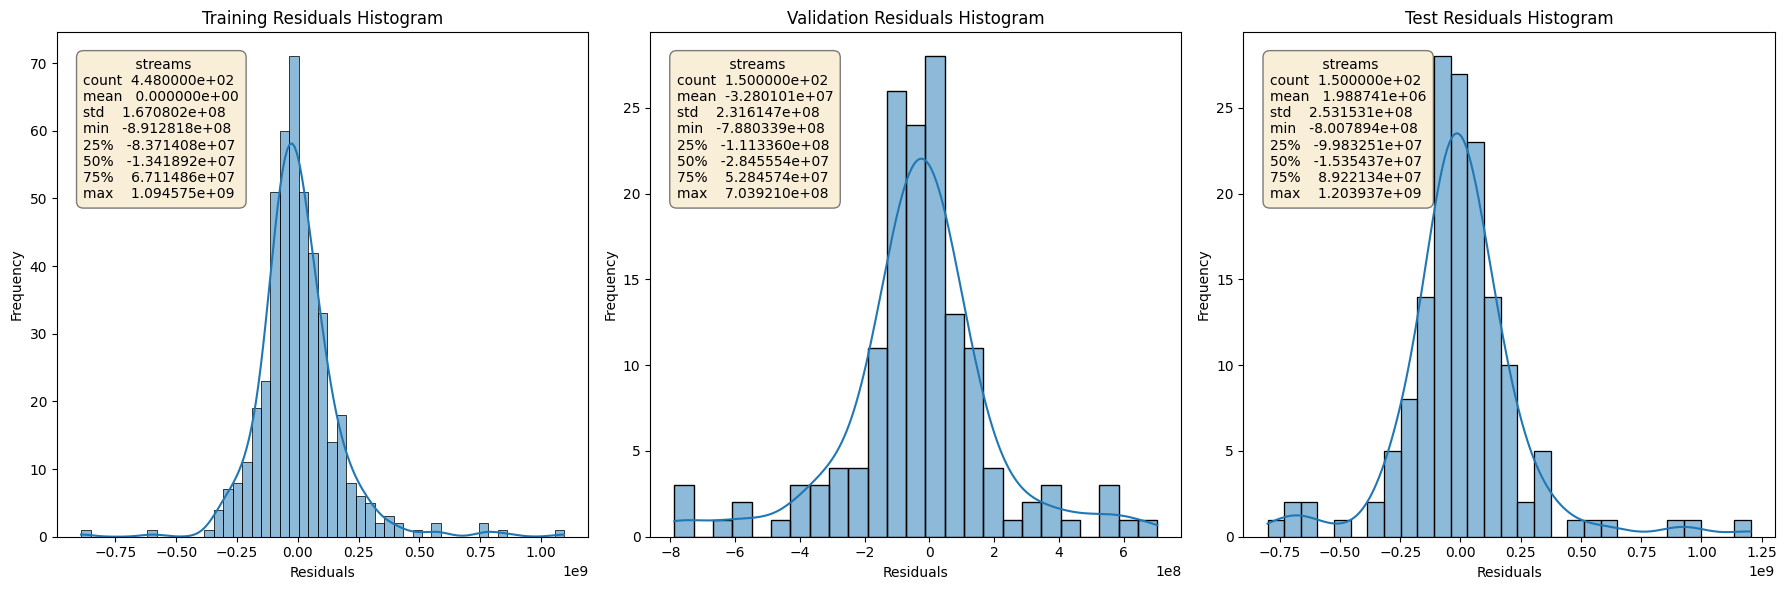

In [120]:
# Calculate residuals for each partition
train_residuals = y_train - y_train_pred_tuned_reg
val_residuals = y_val - y_val_pred_tuned_reg
test_residuals = y_test - y_test_pred_tuned_reg

# Plot histograms of the residuals
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Residuals
sns.histplot(train_residuals, kde=True, ax=axs[0])
axs[0].set_title('Training Residuals Histogram')
axs[0].set_xlabel('Residuals')
axs[0].set_ylabel('Frequency')
train_stats = pd.DataFrame(train_residuals).describe().round(2) # Round to 2 decimal places
axs[0].text(0.05, 0.95, train_stats.to_string(), transform=axs[0].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Validation Residuals
sns.histplot(val_residuals, kde=True, ax=axs[1])
axs[1].set_title('Validation Residuals Histogram')
axs[1].set_xlabel('Residuals')
axs[1].set_ylabel('Frequency')
val_stats = pd.DataFrame(val_residuals).describe().round(2) # Round to 2 decimal places
axs[1].text(0.05, 0.95, val_stats.to_string(), transform=axs[1].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

# Test Residuals
sns.histplot(test_residuals, kde=True, ax=axs[2])
axs[2].set_title('Test Residuals Histogram')
axs[2].set_xlabel('Residuals')
axs[2].set_ylabel('Frequency')
test_stats = pd.DataFrame(test_residuals).describe().round(2) # Round to 2 decimal places
axs[2].text(0.05, 0.95, test_stats.to_string(), transform=axs[2].transAxes, va='top', bbox=dict(boxstyle='round,pad=0.5', fc='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

Dataframes with actual and predicted streams created.


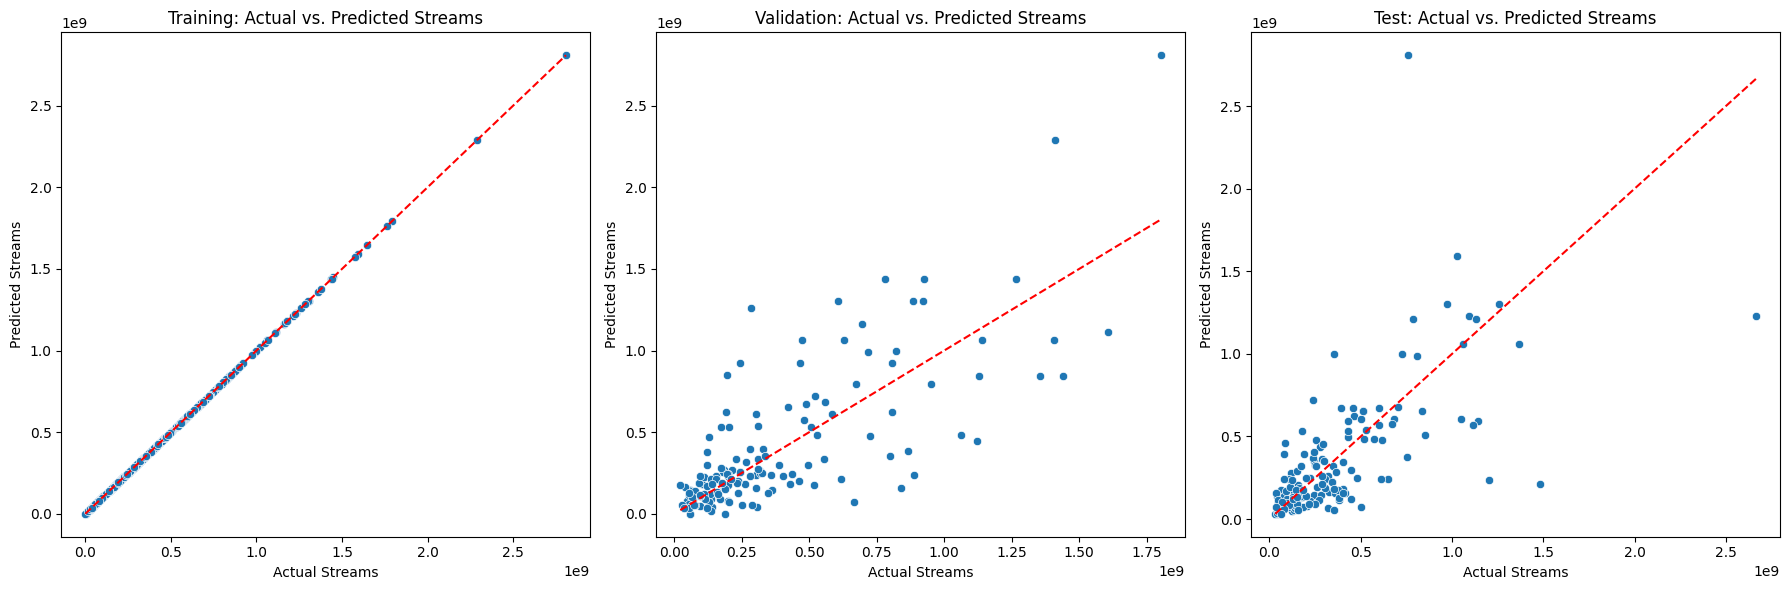

In [121]:
# Plot actual vs. predicted prices for each partition
fig, axs = plt.subplots(1, 3, figsize=(18, 6)) # Increased figure size for better readability

# Training Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=train_results, ax=axs[0])
axs[0].set_title('Training: Actual vs. Predicted Streams')
axs[0].set_xlabel('Actual Streams')
axs[0].set_ylabel('Predicted Streams')
axs[0].plot([train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           [train_results['Actual_Streams'].min(), train_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Validation Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=val_results, ax=axs[1])
axs[1].set_title('Validation: Actual vs. Predicted Streams')
axs[1].set_xlabel('Actual Streams')
axs[1].set_ylabel('Predicted Streams')
axs[1].plot([val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           [val_results['Actual_Streams'].min(), val_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

# Test Partition
sns.scatterplot(x='Actual_Streams', y='Predicted_Streams', data=test_results, ax=axs[2])
axs[2].set_title('Test: Actual vs. Predicted Streams')
axs[2].set_xlabel('Actual Streams')
axs[2].set_ylabel('Predicted Streams')
axs[2].plot([test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           [test_results['Actual_Streams'].min(), test_results['Actual_Streams'].max()],
           color='red', linestyle='--') # Add a diagonal line for reference

print("Dataframes with actual and predicted streams created.")
plt.tight_layout()
plt.show()

**Prompt 22:** How did performance change?

**Answer:** The model improved overall. The test partition's RMSE score saw an improvement compared to the previous model, signifying this model's predictions were a little better at being more accurate and closer to the actual values, as the validation partition was, for example. The R-squared measurement demonstrated a significant increase across both the validation and testing partitions, rising by approximately 20%. This increase indicates that the model fits much better than the previous one and can more accurately represent the variance in the dependent variable. The residual histograms yielded less extreme values, particularly for the testing partition, and showed a decreased mean and standard deviation. Finally, the actual vs. predicted streams scatterplots showed that the test partition, while still performing worse than the other partitions, performed noticeably better than the previous testing partition.

**Prompt 24:** Check for feature importance again. Which variables are the most important? Did any predictors go unused?

In [122]:
import pandas as pd

# Get the feature importances from the tuned regression tree model
feature_importances_tuned_reg_tree = tuned_reg_tree_model.feature_importances_

# Get the feature names from the training data (assuming X_train is consistent)
feature_names_reg_tree = X_train.columns

# Create a pandas Series to easily view feature importances with their names
feature_importance_series_tuned_reg_tree = pd.Series(feature_importances_tuned_reg_tree, index=feature_names_reg_tree)

# Sort the feature importances in descending order
sorted_feature_importances_tuned_reg_tree = feature_importance_series_tuned_reg_tree.sort_values(ascending=False)

# Print the sorted feature importances
print("Feature Importances for Tuned Regression Tree:")
print(sorted_feature_importances_tuned_reg_tree)

Feature Importances for Tuned Regression Tree:
in_spotify_playlists    0.816162
in_deezer_playlists     0.069178
released_year           0.034999
in_deezer_charts        0.031739
in_spotify_charts       0.016559
bpm                     0.014206
in_shazam_charts        0.013642
speechiness_%           0.003515
artist_count            0.000000
released_month          0.000000
in_apple_playlists      0.000000
in_apple_charts         0.000000
danceability_%          0.000000
released_day            0.000000
valence_%               0.000000
energy_%                0.000000
instrumentalness_%      0.000000
acousticness_%          0.000000
liveness_%              0.000000
key_A#                  0.000000
key_B                   0.000000
key_C#                  0.000000
key_D                   0.000000
key_D#                  0.000000
key_E                   0.000000
key_F                   0.000000
key_F#                  0.000000
key_G                   0.000000
key_G#                  0.000

**Answer:** The variables that were deemed most important were **in_spotify_playlists**, **in_deezer_playlists**, **released_year**, and **in_deezer_charts**. The unused predictors consisting of **artist_count**, **released_month**, **in_apple_playlists**, **in_apple_charts**, **danceability_%**, **released_day**, **valence_%**, **energy_%**, **instrumentalness_%**, **acousticness_%**, **liveness_%**, **key_A#**, **key_B**, **key_C#**, **key_D#**, **key_E#**, **key_F**, **key_F#**, **key_G**, **key_G#**, and **node_Minor**.